# Donify — Exploration & Évaluation du modèle (XGBoost)
Ce notebook sert à :
- Charger le dataset et le modèle XGBoost sauvegardé
- Évaluer les performances sur le test set
- Tracer la courbe Precision–Recall
- Trouver un seuil optimal (F1 / ou seuil métier)
- Visualiser la matrice de confusion au seuil choisi

## Imports

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_SEED = 42
TARGET = "accepted_label"

## Chemins

In [6]:
DATA_PATH = "../data/matching_training_dataset.csv"
MODEL_PATH = "../models/xgboost.joblib"

print("DATA_PATH:", os.path.abspath(DATA_PATH))
print("MODEL_PATH:", os.path.abspath(MODEL_PATH))

DATA_PATH: c:\Donify\project-root\ai\data\matching_training_dataset.csv
MODEL_PATH: c:\Donify\project-root\ai\models\xgboost.joblib


## Charger dataset + split identique au training

In [7]:
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Dataset shape:", df.shape)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nTarget proportion:\n", y.value_counts(normalize=True).round(4))

Dataset shape: (5000000, 11)
Train: (4000000, 10) Test: (1000000, 10)

Target proportion:
 accepted_label
0    0.8405
1    0.1595
Name: proportion, dtype: float64


## Charger modèle XGBoost sauvegardé

In [4]:
pipe = load(MODEL_PATH)

y_pred_05 = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print("OK: modèle chargé et proba calculées.")

OK: modèle chargé et proba calculées.


## Métriques au seuil 0.5 (référence)

In [8]:
acc = accuracy_score(y_test, y_pred_05)
prec = precision_score(y_test, y_pred_05, zero_division=0)
rec = recall_score(y_test, y_pred_05, zero_division=0)
f1 = f1_score(y_test, y_pred_05, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("=== Metrics (threshold = 0.5) ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

=== Metrics (threshold = 0.5) ===
Accuracy : 0.6193
Precision: 0.2507
Recall   : 0.6975
F1-score : 0.3688
ROC-AUC  : 0.708


## Courbe Precision–Recall + seuil optimal (max F1)

In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F1 pour chaque point
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)

# ⚠ thresholds a une longueur = len(precisions)-1
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print("=== Best threshold (max F1) ===")
print("Best threshold:", round(best_threshold, 4))
print("Best F1       :", round(f1_scores[best_idx], 4))
print("Precision     :", round(precisions[best_idx], 4))
print("Recall        :", round(recalls[best_idx], 4))

=== Best threshold (max F1) ===
Best threshold: 0.5432
Best F1       : 0.3732
Precision     : 0.2689
Recall        : 0.6094


## Plot PR Curve

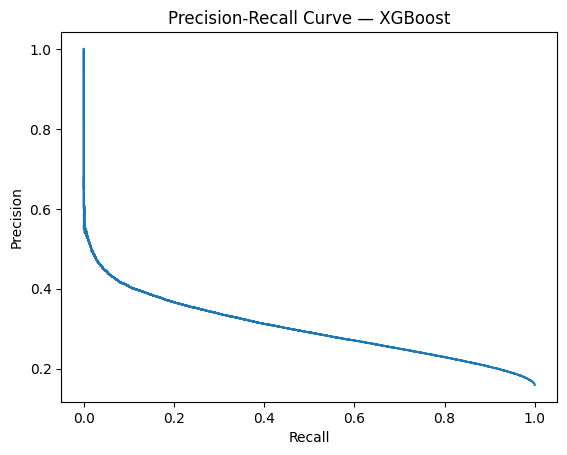

In [10]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.show()

## Confusion Matrix au seuil optimal

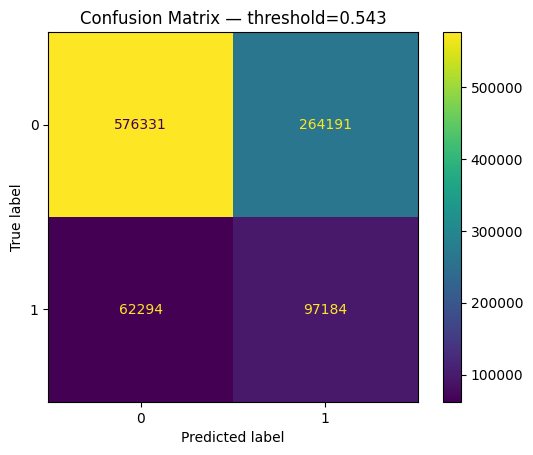

Metrics @ optimal threshold
Precision: 0.2689
Recall   : 0.6094
F1       : 0.3732


In [11]:
y_pred_opt = (y_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix — threshold={best_threshold:.3f}")
plt.show()

print("Metrics @ optimal threshold")
print("Precision:", round(precision_score(y_test, y_pred_opt, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_opt, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, y_pred_opt, zero_division=0), 4))

## TOP-K Metrics

In [12]:

# Construire dataframe résultats
results = X_test.copy()
results["true_label"] = y_test.values
results["proba"] = y_proba

# Trier par score décroissant
results_sorted = results.sort_values("proba", ascending=False)

def compute_topk_metrics(results_df, k):
    top_k = results_df.head(k)
    
    precision_at_k = top_k["true_label"].mean()
    recall_at_k = top_k["true_label"].sum() / results_df["true_label"].sum()
    
    return precision_at_k, recall_at_k


# Tester pour plusieurs valeurs de K
for k in [100, 500, 1000, 5000]:
    p_at_k, r_at_k = compute_topk_metrics(results_sorted, k)
    print(f"K={k}")
    print("Precision@K:", round(p_at_k, 4))
    print("Recall@K   :", round(r_at_k, 4))
    print("-"*30)

K=100
Precision@K: 0.56
Recall@K   : 0.0004
------------------------------
K=500
Precision@K: 0.562
Recall@K   : 0.0018
------------------------------
K=1000
Precision@K: 0.545
Recall@K   : 0.0034
------------------------------
K=5000
Precision@K: 0.5028
Recall@K   : 0.0158
------------------------------


 ## Gain Chart

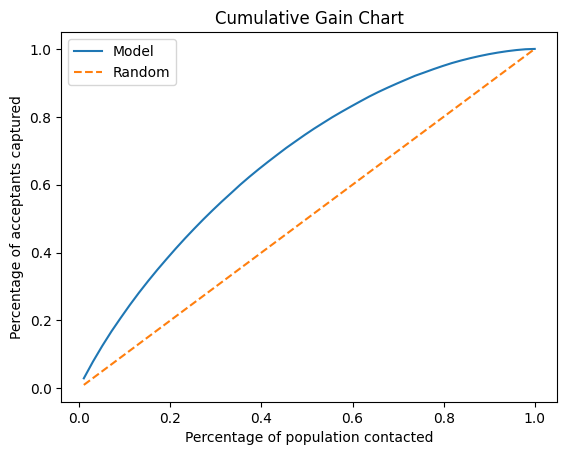

In [13]:

percentages = np.linspace(0.01, 1.0, 50)
gains = []

total_positives = results_sorted["true_label"].sum()

for p in percentages:
    k = int(len(results_sorted) * p)
    top_k = results_sorted.head(k)
    gain = top_k["true_label"].sum() / total_positives
    gains.append(gain)

plt.plot(percentages, gains, label="Model")
plt.plot(percentages, percentages, linestyle="--", label="Random")
plt.xlabel("Percentage of population contacted")
plt.ylabel("Percentage of acceptants captured")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.show()